In [12]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import cv2
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

In [16]:
path = r'C:\Users\samik\Downloads\Flowers'

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\Users\samik\Downloads\Flowers\daisy\100080576_f52e8ee070_n.jpg
C:\Users\samik\Downloads\Flowers\daisy\10140303196_b88d3d6cec.jpg
C:\Users\samik\Downloads\Flowers\daisy\10172379554_b296050f82_n.jpg
C:\Users\samik\Downloads\Flowers\daisy\10172567486_2748826a8b.jpg
C:\Users\samik\Downloads\Flowers\daisy\10172636503_21bededa75_n.jpg
C:\Users\samik\Downloads\Flowers\daisy\102841525_bd6628ae3c.jpg
C:\Users\samik\Downloads\Flowers\daisy\10300722094_28fa978807_n.jpg
C:\Users\samik\Downloads\Flowers\daisy\1031799732_e7f4008c03.jpg
C:\Users\samik\Downloads\Flowers\daisy\10391248763_1d16681106_n.jpg
C:\Users\samik\Downloads\Flowers\daisy\10437754174_22ec990b77_m.jpg
C:\Users\samik\Downloads\Flowers\daisy\10437770546_8bb6f7bdd3_m.jpg
C:\Users\samik\Downloads\Flowers\daisy\10437929963_bc13eebe0c.jpg
C:\Users\samik\Downloads\Flowers\daisy\10466558316_a7198b87e2.jpg
C:\Users\samik\Downloads\Flowers\daisy\10555749515_13a12a026e.jpg
C:\Users\samik\Downloads\Flowers\daisy\10555815624_dc211569b0.jpg
C

In [18]:
X = []
Y = []
base_path = r'C:\Users\samik\Downloads\Flowers'

flower_daisy = os.listdir(os.path.join(base_path, 'daisy'))
flower_dandelion = os.listdir(os.path.join(base_path, 'dandelion'))
flower_rose = os.listdir(os.path.join(base_path, 'rose'))
flower_sunflower = os.listdir(os.path.join(base_path, 'sunflower'))
flower_tulip = os.listdir(os.path.join(base_path, 'tulip'))

In [19]:
print('Number of daisy images: ', len(flower_daisy))
print('Number of dandelion images: ', len(flower_dandelion))
print('Number of rose images: ', len(flower_rose))
print('Number of sunflower images: ', len(flower_sunflower))
print('Number of tulip images: ', len(flower_tulip))

Number of daisy images:  760
Number of dandelion images:  1052
Number of rose images:  782
Number of sunflower images:  733
Number of tulip images:  984


In [20]:
def assign_label(img, flower_type):
    return flower_type

In [21]:
def make_train_data(flower_type, DIR):
    for img in tqdm(os.listdir(DIR)):
        label = assign_label(img, flower_type)
        path = os.path.join(DIR, img)
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (150, 150))
        
        X.append(np.array(img))
        Y.append(str(label))

In [23]:
BASE_DIR = r'C:\Users\samik\Downloads\Flowers'
make_train_data('Daisy', os.path.join(BASE_DIR, 'daisy'))
print(len(X))

100%|████████████████████████████████████████████████████████████████████████████████| 760/760 [00:08<00:00, 90.45it/s]

760


In [24]:
make_train_data('Dandelion', os.path.join(BASE_DIR, 'dandelion'))
print(f"Total images after Dandelion: {len(X)}")

100%|██████████████████████████████████████████████████████████████████████████████| 1052/1052 [00:11<00:00, 89.33it/s]

Total images after Dandelion: 1812


In [25]:
make_train_data('Rose', os.path.join(BASE_DIR, 'rose'))
print(f"Total images after Rose: {len(X)}")

100%|████████████████████████████████████████████████████████████████████████████████| 782/782 [00:08<00:00, 90.62it/s]

Total images after Rose: 2594


In [26]:
make_train_data('Sunflower', os.path.join(BASE_DIR, 'sunflower'))
print(f"Total images after Sunflower: {len(X)}")

100%|████████████████████████████████████████████████████████████████████████████████| 733/733 [00:08<00:00, 91.11it/s]

Total images after Sunflower: 3327


In [27]:
make_train_data('Tulip', os.path.join(BASE_DIR, 'tulip'))
print(f"Total images after Tulip: {len(X)}")

100%|████████████████████████████████████████████████████████████████████████████████| 984/984 [00:10<00:00, 91.09it/s]

Total images after Tulip: 4311


In [28]:
labelEncoder = LabelEncoder()
Y = labelEncoder.fit_transform(Y)
Y = to_categorical(Y,5)
X = np.array(X)
X = X/ 255

In [29]:
# Splitting the data into train and test
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=42, test_size=0.2)

print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (3448, 150, 150, 3)
x_test shape:  (863, 150, 150, 3)
y_train shape:  (3448, 5)
y_test shape:  (863, 5)


In [30]:
from keras.models import Sequential

from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization
 
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same',
                    activation ='relu', input_shape = (150,150,3)))
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same',
                    activation ='relu'))

model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))
    
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',
                    activation ='relu'))
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',
                    activation ='relu'))

model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(5, activation = "softmax"))
 
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
 
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

C:\Users\samik\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 150, 150, 32)        │          25,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 75, 75, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 87616)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      22,429,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,514,725 (85.89 MB)

 Trainable params: 22,514,725 (85.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 62s 549ms/step - accuracy: 0.3628 - loss: 1.4964 - val_accuracy: 0.4600 - val_loss: 1.2820
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 60s 556ms/step - accuracy: 0.4751 - loss: 1.2281 - val_accuracy: 0.4959 - val_loss: 1.1921
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 60s 551ms/step - accuracy: 0.5412 - loss: 1.1381 - val_accuracy: 0.5539 - val_loss: 1.1898
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 61s 566ms/step - accuracy: 0.5751 - loss: 1.0902 - val_accuracy: 0.5365 - val_loss: 1.1017
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 74s 683ms/step - accuracy: 0.6282 - loss: 0.9732 - val_accuracy: 0.5805 - val_loss: 1.0664
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 68s 630ms/step - accuracy: 0.6830 - loss: 0.8604 - val_accuracy: 0.5724 - val_loss: 1.0736
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 68s 630ms/step - accuracy: 0.7161 - loss: 0.7526 - val_accuracy: 0.6165 - val_loss: 1.0184
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 58s 541ms/step - accuracy: 0.7697 - loss: 0

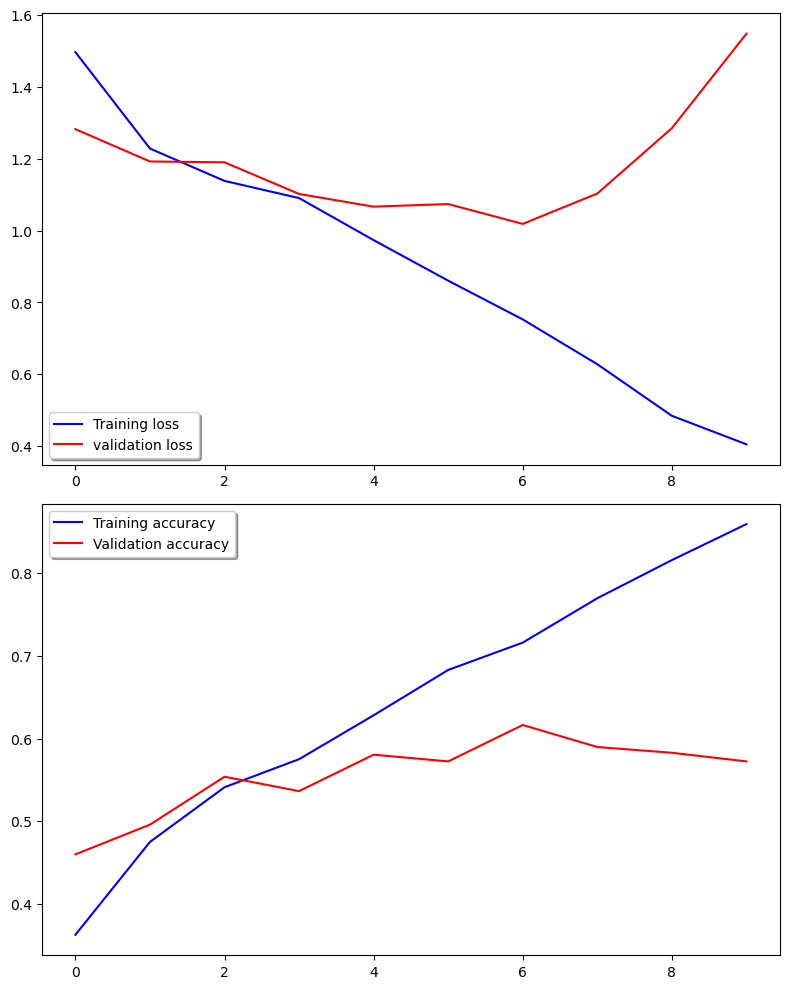

In [32]:
fig, ax = plt.subplots(2,1, figsize=(8, 10))

ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="validation loss")
ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r', label="Validation accuracy")
ax[1].legend(loc='best', shadow=True)

plt.tight_layout()
plt.show()

In [33]:
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(x_test, y_test, batch_size=128)
print("test loss, test acc:", results)

Evaluate on test data
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 393ms/step - accuracy: 0.5724 - loss: 1.5477
test loss, test acc: [1.547684907913208, 0.5724217891693115]


In [34]:
# print classification report
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred,axis = 1)
y_true = np.argmax(y_test,axis = 1)
print(classification_report(y_true, y_pred_classes))
 

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step
              precision    recall  f1-score   support

           0       0.54      0.61      0.57       165
           1       0.60      0.73      0.66       233
           2       0.58      0.29      0.39       150
           3       0.56      0.48      0.52       137
           4       0.57      0.64      0.60       178

    accuracy                           0.57       863
   macro avg       0.57      0.55      0.55       863
weighted avg       0.57      0.57      0.56       863



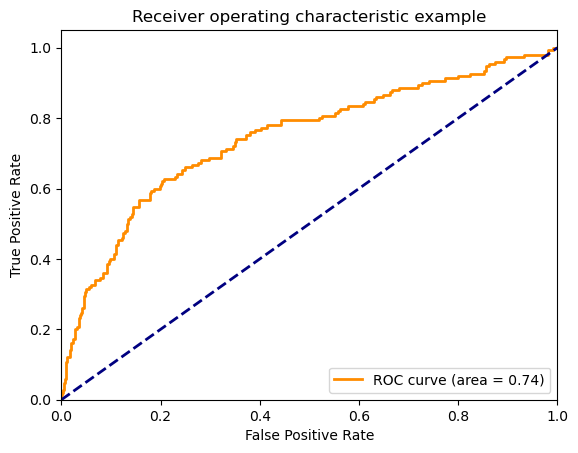

In [35]:
# plot roc curve
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(5):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
     
# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
 
plt.figure()
lw = 2
plt.plot(fpr[2], tpr[2], color='darkorange',
            lw=lw, label='ROC curve (area = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

 

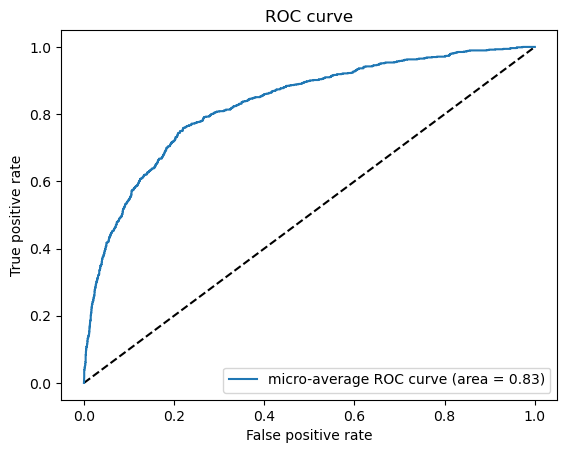

In [36]:
# plot auc curve
plt.figure()
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr["micro"], tpr["micro"], label='micro-average ROC curve (area = {0:0.2f})'
                                        ''.format(roc_auc["micro"]))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()
